# CAFA-6 High-Performance Offline Solution

Notebook này bám sát hướng solution ban đầu: dùng protein language model ESM-2 làm backbone chính, kết hợp thêm ProtCNN/BiLSTM sequence models và ensemble để tối ưu chất lượng dự đoán GO terms.

Mục tiêu hiện tại là performance offline trên split từ train data, chưa tối ưu cho real-time production.

Pipeline:

1. Load CAFA-6 data.
2. Tách held-out test split theo protein-level.
3. Chọn label space lớn hơn cho GO terms phổ biến.
4. Tạo ESM-2 frozen embeddings.
5. Train ESM-MLP classifier.
6. Train optional ProtCNN và BiLSTM-Attention.
7. Ensemble prediction.
8. Lưu model artifacts và input cho CAFA-evaluator-PK chính thức.

In [1]:
# =============================
# -1. Kaggle GPU/PyTorch bootstrap for Save Version
# =============================
# This notebook is intended to run in Kaggle "Save Version / Run All" mode.
# Therefore it does NOT reinstall PyTorch or require kernel restart.
# Use Kaggle Accelerator = GPU T4 x2 or L4. P100 may fail with recent PyTorch
# wheels because P100 is sm_60 while the wheel may only include sm_70+ kernels.

import subprocess


def _run(cmd):
    return subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)


def _gpu_info_from_nvidia_smi():
    result = _run(["nvidia-smi", "--query-gpu=name,compute_cap", "--format=csv,noheader"])
    if result.returncode != 0:
        print("[BOOTSTRAP] nvidia-smi not available or no GPU detected.")
        return []
    rows = []
    for line in result.stdout.strip().splitlines():
        parts = [p.strip() for p in line.split(',')]
        if parts:
            rows.append((parts[0], parts[1] if len(parts) > 1 else "unknown"))
    return rows


gpu_rows = _gpu_info_from_nvidia_smi()
for i, (name, cap) in enumerate(gpu_rows):
    print(f"[BOOTSTRAP] GPU{i}: {name} | compute capability {cap}")

import torch
print(f"[BOOTSTRAP] torch: {torch.__version__}")
print(f"[BOOTSTRAP] torch CUDA version: {torch.version.cuda}")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. In Kaggle Settings, set Accelerator to GPU T4 x2 or L4.")

arch_list = set(torch.cuda.get_arch_list())
print(f"[BOOTSTRAP] torch arch list: {sorted(arch_list)}")
for i in range(torch.cuda.device_count()):
    major, minor = torch.cuda.get_device_capability(i)
    arch = f"sm_{major}{minor}"
    name = torch.cuda.get_device_name(i)
    if arch not in arch_list:
        raise RuntimeError(
            f"GPU{i} {name} has arch {arch}, but this PyTorch build does not support it. "
            "For Kaggle Save Version, switch Accelerator to T4 x2 or L4. "
            "Do not use P100 with this runtime."
        )

# Smoke test on every visible GPU.
for i in range(torch.cuda.device_count()):
    _ = (torch.ones(1, device=f"cuda:{i}") + 1).cpu()
print(f"[BOOTSTRAP] CUDA smoke test passed on {torch.cuda.device_count()} GPU(s).")

[BOOTSTRAP] GPU0: Tesla T4 | compute capability 7.5
[BOOTSTRAP] GPU1: Tesla T4 | compute capability 7.5
[BOOTSTRAP] torch: 2.10.0+cu128
[BOOTSTRAP] torch CUDA version: 12.8
[BOOTSTRAP] torch arch list: ['sm_100', 'sm_120', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
[BOOTSTRAP] CUDA smoke test passed on 2 GPU(s).


In [2]:
# =============================
# 0. Configuration
# =============================
import os
import re
import gc
import json
import time
import math
import random
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

CONFIG = {
    # Runtime. Set force_device to "cpu" or "cuda" if you want to override auto detection.
    # For Kaggle Save Version, use Accelerator = T4 x2 or L4. P100 is intentionally rejected if unsupported.
    "force_device": None,

    # Data/split. Split is protein-level: train/valid/test = 70/15/15 by default.
    "valid_size": 0.15,
    "test_size": 0.15,
    "split_mode": "stratified_protein",

    # Larger label space for stronger CAFA-style coverage.
    "max_labels": 3000,
    "min_label_freq": 8,

    # Protein language model. t30_150M is a strong Kaggle-feasible default.
    # Alternatives: facebook/esm2_t12_35M_UR50D, facebook/esm2_t33_650M_UR50D
    "embedding_model_name": "facebook/esm2_t30_150M_UR50D",
    "embedding_batch_size": 8,
    "embedding_max_length": 1022,
    "embedding_pooling": "mean",
    "use_fp16_embeddings": True,
    "recompute_embeddings": False,
    # Optional: put previous failed Kaggle version output under /kaggle/input.
    # The notebook also auto-searches /kaggle/input/**/embeddings for matching cache files.
    "embedding_cache_input_dirs": ["/kaggle/input/notebooks/qundngdngminhqun/cafa6-offline-realtime-solution/cafa6_high_performance_artifacts"],
    # Optional ProtBERT branch from the original solution. This is heavy.
    "protbert_model_name": "Rostlab/prot_bert",
    "protbert_batch_size": 4,
    "protbert_max_length": 1024,

    # Additional sequence models proposed in the original solution.
    "train_esm_mlp": True,
    "train_protcnn": True,
    "train_bilstm_attention": True,
    "train_protbert": False,  # set True for an additional ProtBERT-MLP ensemble branch

    # Sequence neural model settings.
    "sequence_max_length": 1024,
    "sequence_batch_size": 256,

    # MLP head on top of ESM embeddings.
    "esm_hidden_dims": [1024, 512],
    "esm_dropout": 0.35,
    "esm_batch_size": 512,
    "esm_epochs": 15,

    # ProtCNN.
    "protcnn_epochs": 10,
    "protcnn_dropout": 0.35,

    # BiLSTM-Attention.
    "bilstm_epochs": 8,
    "bilstm_dropout": 0.35,

    # Optimization.
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "pos_weight_clip": 30.0,
    "early_stopping_patience": 3,

    # Evaluation/inference.
    "threshold_grid": [0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50],
    "precision_k_values": [10, 25, 50, 100, 250],
    "inference_top_k": 500,
    "official_eval_top_k": 1500,

    # Ensemble. Only enabled models are used and weights are renormalized.
    "ensemble_weights": {
        "esm_mlp": 0.60,
        "protcnn": 0.25,
        "bilstm_attention": 0.12,
        "protbert_mlp": 0.18,
    },

    # Output.
    "artifact_dir": "/kaggle/working/cafa6_high_performance_artifacts" if Path('/kaggle/working').exists() else "cafa6_high_performance_artifacts",
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[CONFIG] Device: {DEVICE}")
print(json.dumps(CONFIG, indent=2))

[CONFIG] Device: cuda
{
  "force_device": null,
  "valid_size": 0.15,
  "test_size": 0.15,
  "split_mode": "stratified_protein",
  "max_labels": 3000,
  "min_label_freq": 8,
  "embedding_model_name": "facebook/esm2_t30_150M_UR50D",
  "embedding_batch_size": 8,
  "embedding_max_length": 1022,
  "embedding_pooling": "mean",
  "use_fp16_embeddings": true,
  "recompute_embeddings": false,
  "embedding_cache_input_dirs": [
    "/kaggle/input/notebooks/qundngdngminhqun/cafa6-offline-realtime-solution/cafa6_high_performance_artifacts"
  ],
  "protbert_model_name": "Rostlab/prot_bert",
  "protbert_batch_size": 4,
  "protbert_max_length": 1024,
  "train_esm_mlp": true,
  "train_protcnn": true,
  "train_bilstm_attention": true,
  "train_protbert": false,
  "sequence_max_length": 1024,
  "sequence_batch_size": 256,
  "esm_hidden_dims": [
    1024,
    512
  ],
  "esm_dropout": 0.35,
  "esm_batch_size": 512,
  "esm_epochs": 15,
  "protcnn_epochs": 10,
  "protcnn_dropout": 0.35,
  "bilstm_epochs": 

In [3]:
# =============================
# 1. Path discovery and data loading
# =============================
def discover_cafa_base_dir():
    candidates = [
        Path('/kaggle/input/competitions/cafa-6-protein-function-prediction'),
        Path('/kaggle/input/cafa-6-protein-function-prediction'),
        Path('/kaggle/input/cafa6'),
        Path('/kaggle/input'),
        Path.cwd(),
        Path.cwd() / 'cafa6',
    ]
    required = [Path('Train/train_sequences.fasta'), Path('Train/train_terms.tsv')]
    for base in candidates:
        if all((base / r).exists() for r in required):
            return base
    for root in [Path('/kaggle/input'), Path.cwd()]:
        if not root.exists():
            continue
        for seq_file in root.rglob('train_sequences.fasta'):
            base = seq_file.parent.parent if seq_file.parent.name.lower() == 'train' else seq_file.parent
            if all((base / r).exists() for r in required):
                return base
    raise FileNotFoundError('Cannot find CAFA data with Train/train_sequences.fasta and Train/train_terms.tsv')

BASE_DIR = discover_cafa_base_dir()
TRAIN_DIR = BASE_DIR / 'Train'
FILES = {
    'train_seq': TRAIN_DIR / 'train_sequences.fasta',
    'train_terms': TRAIN_DIR / 'train_terms.tsv',
    'train_tax': TRAIN_DIR / 'train_taxonomy.tsv',
    'ia': BASE_DIR / 'IA.tsv',
    'obo': TRAIN_DIR / 'go-basic.obo',
    'test_seq': BASE_DIR / 'Test' / 'testsuperset.fasta',
    'sample_submission': BASE_DIR / 'sample_submission.tsv',
}
print(f"[PATH] BASE_DIR = {BASE_DIR}")
for name, path in FILES.items():
    print(f"[PATH] {name:18s}: {path} | exists={path.exists()}")


def extract_uniprot_id(header_line: str) -> str:
    token = header_line.strip()
    if token.startswith('>'):
        token = token[1:]
    token = token.split()[0]
    if '|' in token:
        parts = token.split('|')
        if len(parts) >= 2 and parts[1]:
            return parts[1]
    return token


def load_fasta(filepath: Path) -> dict[str, str]:
    sequences = {}
    current_id = None
    current_seq = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if current_id is not None:
                    sequences[current_id] = ''.join(current_seq)
                current_id = extract_uniprot_id(line)
                current_seq = []
            else:
                current_seq.append(line.upper())
        if current_id is not None:
            sequences[current_id] = ''.join(current_seq)
    return sequences

start = time.time()
sequences = load_fasta(FILES['train_seq'])
train_terms = pd.read_csv(FILES['train_terms'], sep='\t', header=None, names=['EntryID', 'GO_Term', 'Aspect'])
train_tax = pd.read_csv(FILES['train_tax'], sep='\t', header=None, names=['EntryID', 'Taxonomy']) if FILES['train_tax'].exists() else pd.DataFrame(columns=['EntryID', 'Taxonomy'])
ia_scores = pd.read_csv(FILES['ia'], sep='\t', header=None, names=['GO_Term', 'IA_Score']) if FILES['ia'].exists() else pd.DataFrame(columns=['GO_Term', 'IA_Score'])
seq_df = pd.DataFrame({'EntryID': list(sequences.keys()), 'Sequence': list(sequences.values())})
seq_df['Length'] = seq_df['Sequence'].str.len()
annotated_ids = sorted(set(sequences).intersection(set(train_terms['EntryID'])))

print(f"[LOAD] sequences: {len(sequences):,}")
print(f"[LOAD] train_terms rows: {len(train_terms):,}")
print(f"[LOAD] unique proteins in terms: {train_terms['EntryID'].nunique():,}")
print(f"[LOAD] unique GO terms: {train_terms['GO_Term'].nunique():,}")
print(f"[LOAD] proteins with sequence + labels: {len(annotated_ids):,}")
print(f"[LOAD] elapsed: {time.time() - start:.1f}s")

[PATH] BASE_DIR = /kaggle/input/competitions/cafa-6-protein-function-prediction
[PATH] train_seq         : /kaggle/input/competitions/cafa-6-protein-function-prediction/Train/train_sequences.fasta | exists=True
[PATH] train_terms       : /kaggle/input/competitions/cafa-6-protein-function-prediction/Train/train_terms.tsv | exists=True
[PATH] train_tax         : /kaggle/input/competitions/cafa-6-protein-function-prediction/Train/train_taxonomy.tsv | exists=True
[PATH] ia                : /kaggle/input/competitions/cafa-6-protein-function-prediction/IA.tsv | exists=True
[PATH] obo               : /kaggle/input/competitions/cafa-6-protein-function-prediction/Train/go-basic.obo | exists=True
[PATH] test_seq          : /kaggle/input/competitions/cafa-6-protein-function-prediction/Test/testsuperset.fasta | exists=True
[PATH] sample_submission : /kaggle/input/competitions/cafa-6-protein-function-prediction/sample_submission.tsv | exists=True
[LOAD] sequences: 82,404
[LOAD] train_terms rows: 53

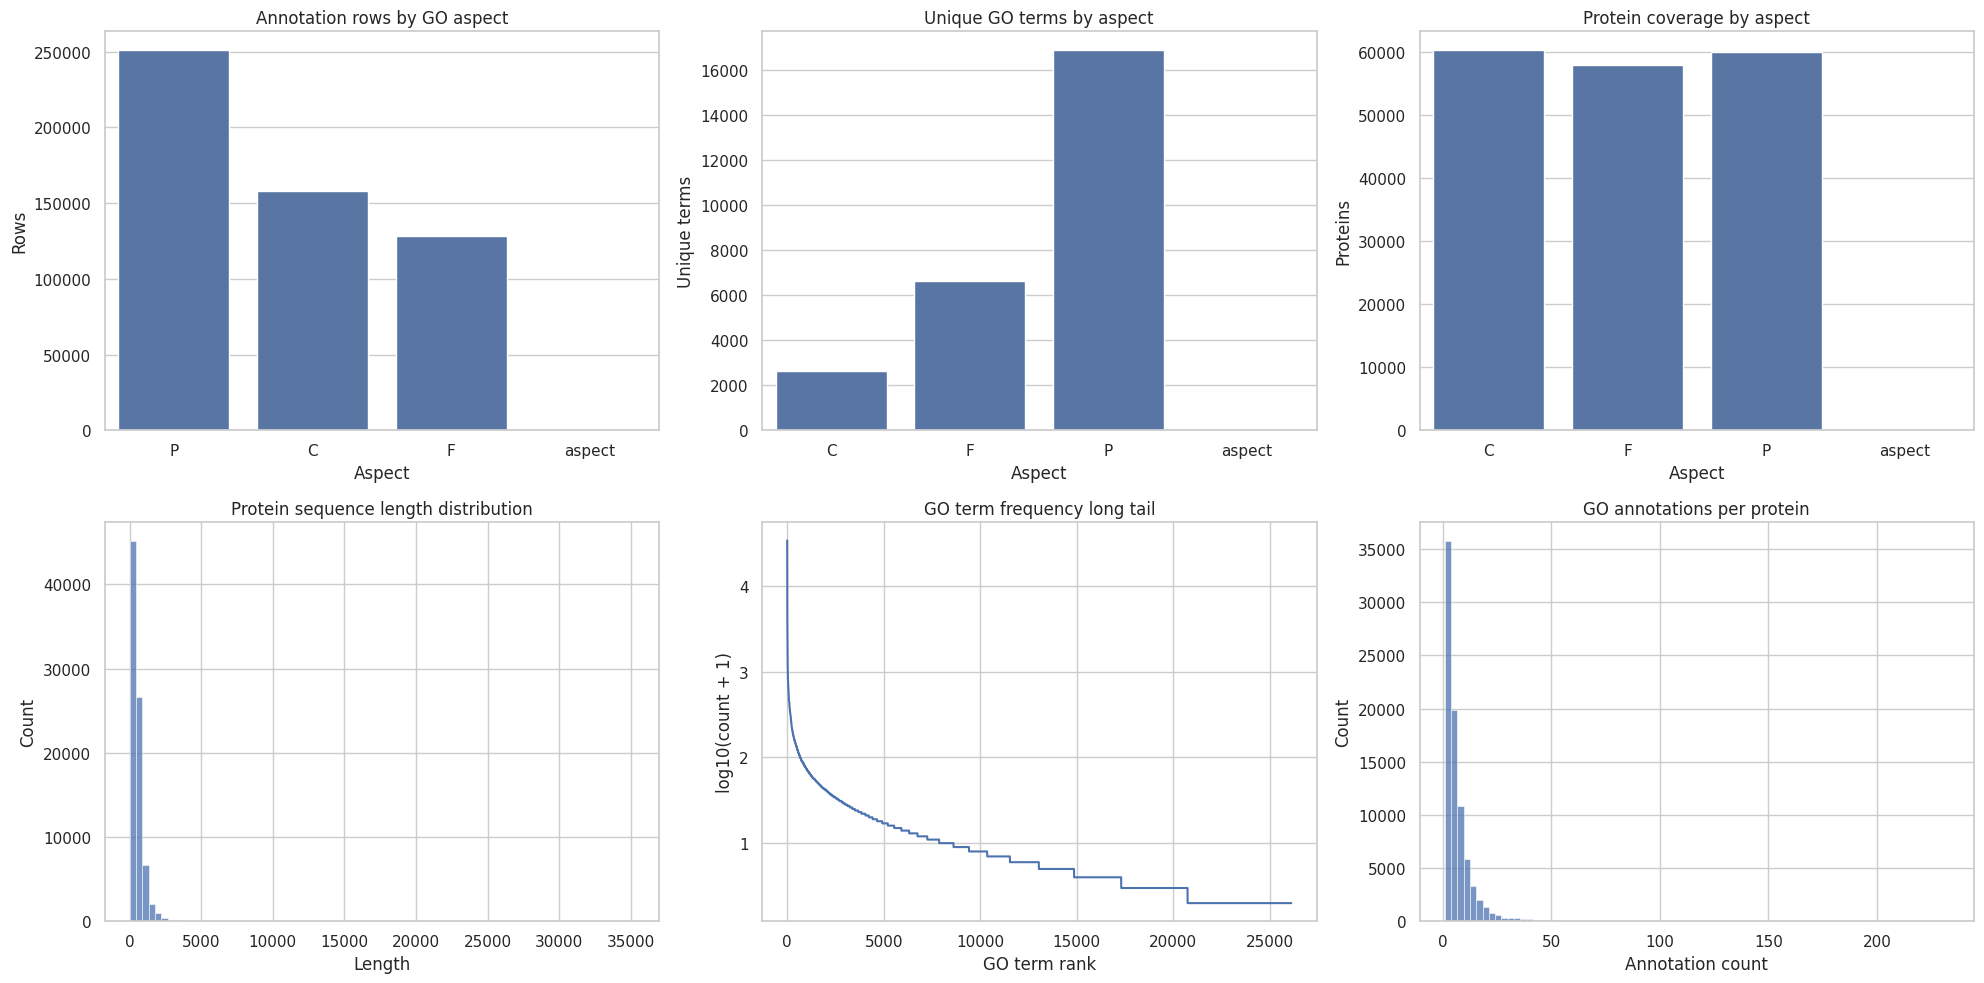

[EDA] Aspect counts:
Aspect
P         250805
C         157770
F         128452
aspect         1

[EDA] Sequence length summary:
count    82404.000000
mean       525.788287
std        521.574869
min          3.000000
25%        250.000000
50%        409.000000
75%        630.000000
max      35213.000000

[EDA] Top 20 GO terms:
GO_Term
GO:0005515    33713
GO:0005634    13283
GO:0005829    13040
GO:0005886    10150
GO:0005737     9442
GO:0005739     5807
GO:0005654     5065
GO:0016020     3563
GO:0042802     3547
GO:0005576     3241
GO:0005783     2837
GO:0005615     2391
GO:0045944     2319
GO:0070062     2130
GO:0005794     2045
GO:0005730     1789
GO:0042803     1627
GO:0003723     1613
GO:0000122     1551
GO:0009507     1512


In [4]:
# =============================
# 2. EDA inspired by the original solution notebook
# =============================
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

aspect_counts = train_terms['Aspect'].value_counts()
sns.barplot(x=aspect_counts.index, y=aspect_counts.values, ax=axes[0, 0])
axes[0, 0].set_title('Annotation rows by GO aspect')
axes[0, 0].set_xlabel('Aspect')
axes[0, 0].set_ylabel('Rows')

go_term_counts = train_terms.groupby('Aspect')['GO_Term'].nunique()
sns.barplot(x=go_term_counts.index, y=go_term_counts.values, ax=axes[0, 1])
axes[0, 1].set_title('Unique GO terms by aspect')
axes[0, 1].set_xlabel('Aspect')
axes[0, 1].set_ylabel('Unique terms')

proteins_per_aspect = train_terms.groupby('Aspect')['EntryID'].nunique()
sns.barplot(x=proteins_per_aspect.index, y=proteins_per_aspect.values, ax=axes[0, 2])
axes[0, 2].set_title('Protein coverage by aspect')
axes[0, 2].set_xlabel('Aspect')
axes[0, 2].set_ylabel('Proteins')

sns.histplot(seq_df['Length'], bins=80, ax=axes[1, 0])
axes[1, 0].set_title('Protein sequence length distribution')
axes[1, 0].set_xlabel('Length')

term_counts = train_terms['GO_Term'].value_counts()
axes[1, 1].plot(np.arange(len(term_counts)), np.log10(term_counts.values + 1))
axes[1, 1].set_title('GO term frequency long tail')
axes[1, 1].set_xlabel('GO term rank')
axes[1, 1].set_ylabel('log10(count + 1)')

ann_per_protein = train_terms.groupby('EntryID').size()
sns.histplot(ann_per_protein, bins=80, ax=axes[1, 2])
axes[1, 2].set_title('GO annotations per protein')
axes[1, 2].set_xlabel('Annotation count')

plt.tight_layout()
plt.show()

print('[EDA] Aspect counts:')
print(aspect_counts.to_string())
print('\n[EDA] Sequence length summary:')
print(seq_df['Length'].describe().to_string())
print('\n[EDA] Top 20 GO terms:')
print(term_counts.head(20).to_string())

In [5]:
# =============================
# 3. Parse GO ontology metadata
# =============================
def parse_go_obo(path: Path):
    parents = defaultdict(set)
    namespace = {}
    name = {}
    current_id = None
    current_ns = None
    current_name = None
    obsolete = False
    def flush():
        if current_id and not obsolete:
            if current_ns:
                namespace[current_id] = current_ns
            if current_name:
                name[current_id] = current_name
    with open(path, 'r') as f:
        for raw in f:
            line = raw.strip()
            if line == '[Term]':
                flush()
                current_id = None
                current_ns = None
                current_name = None
                obsolete = False
                continue
            if not line or line.startswith('!'):
                continue
            if line.startswith('id: GO:'):
                current_id = line.split('id: ', 1)[1]
            elif line.startswith('name: '):
                current_name = line.split('name: ', 1)[1]
            elif line.startswith('namespace: '):
                current_ns = line.split('namespace: ', 1)[1]
            elif line.startswith('is_obsolete: true'):
                obsolete = True
            elif current_id and line.startswith('is_a: GO:'):
                parents[current_id].add(line.split()[1])
            elif current_id and line.startswith('relationship: part_of GO:'):
                parents[current_id].add(line.split()[2])
        flush()
    return dict(parents), namespace, name

go_parents, go_namespace, go_name = parse_go_obo(FILES['obo']) if FILES['obo'].exists() else ({}, {}, {})
namespace_to_aspect = {
    'molecular_function': 'MF',
    'biological_process': 'BP',
    'cellular_component': 'CC',
}
term_to_aspect = train_terms.groupby('GO_Term')['Aspect'].agg(lambda s: s.mode().iloc[0]).to_dict()
for term, ns in go_namespace.items():
    term_to_aspect.setdefault(term, namespace_to_aspect.get(ns))
ia_dict = dict(zip(ia_scores['GO_Term'], ia_scores['IA_Score'])) if len(ia_scores) else {}
def ia(term):
    return float(ia_dict.get(term, 1.0))

@lru_cache(maxsize=None)
def ancestors(term):
    out = set()
    for p in go_parents.get(term, []):
        out.add(p)
        out.update(ancestors(p))
    return frozenset(out)

print(f"[GO] terms with parents: {len(go_parents):,}")
print(f"[GO] terms with namespace: {len(go_namespace):,}")
print(f"[GO] IA rows: {len(ia_dict):,}")

[GO] terms with parents: 40,119
[GO] terms with namespace: 40,122
[GO] IA rows: 40,122


[LABEL] selected terms: 3,000
[LABEL] min frequency: 8
[LABEL] covered annotation rows: 398,063 / 537,028 (74.12%)
[LABEL] usable proteins after label filtering: 78,523 / 82,404
[LABEL] selected aspects:
P    1971
F     537
C     492


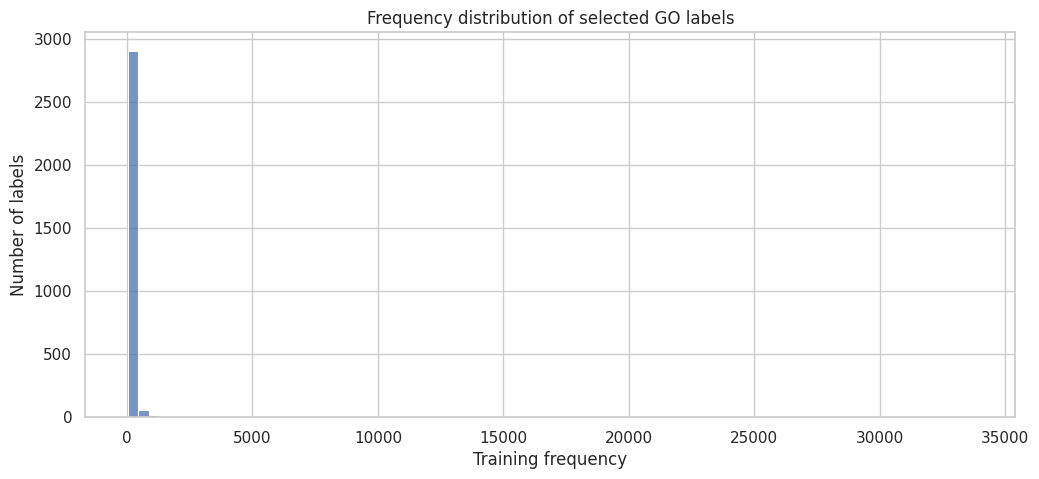

In [6]:
# =============================
# 4. Select larger label universe
# =============================
label_counts = train_terms['GO_Term'].value_counts()
eligible_terms = label_counts[label_counts >= CONFIG['min_label_freq']]
selected_terms = eligible_terms.head(CONFIG['max_labels']).index.tolist()
selected_term_set = set(selected_terms)
term_to_index = {term: i for i, term in enumerate(selected_terms)}
index_to_term = {i: term for term, i in term_to_index.items()}

protein_to_terms_full = train_terms.groupby('EntryID')['GO_Term'].apply(set).to_dict()
protein_to_terms_selected = {
    pid: sorted(set(terms).intersection(selected_term_set))
    for pid, terms in protein_to_terms_full.items()
}
usable_ids = [pid for pid in annotated_ids if len(protein_to_terms_selected.get(pid, [])) > 0]
covered_rows = train_terms['GO_Term'].isin(selected_term_set).sum()

print(f"[LABEL] selected terms: {len(selected_terms):,}")
print(f"[LABEL] min frequency: {CONFIG['min_label_freq']}")
print(f"[LABEL] covered annotation rows: {covered_rows:,} / {len(train_terms):,} ({covered_rows / len(train_terms):.2%})")
print(f"[LABEL] usable proteins after label filtering: {len(usable_ids):,} / {len(annotated_ids):,}")
print('[LABEL] selected aspects:')
print(pd.Series([term_to_aspect.get(t, 'UNK') for t in selected_terms]).value_counts().to_string())

plt.figure(figsize=(12, 5))
sns.histplot(label_counts.loc[selected_terms], bins=80)
plt.title('Frequency distribution of selected GO labels')
plt.xlabel('Training frequency')
plt.ylabel('Number of labels')
plt.show()

[SPLIT] train proteins: 54,965 (70.0%)
[SPLIT] valid proteins: 11,779 (15.0%)
[SPLIT] test proteins : 11,779 (15.0%)
[SPLIT] total usable  : 78,523


,split,proteins,protein_ratio,avg_full_terms_per_protein,avg_selected_terms_per_protein,median_selected_terms_per_protein,proteins_with_MF,proteins_with_BP,proteins_with_CC
0,train,54965,0.699986,6.766579,5.078887,3.0,0,0,0
1,valid,11779,0.150007,6.733084,5.031582,3.0,0,0,0
2,test,11779,0.150007,6.738857,5.062824,3.0,0,0,0


[SPLIT] Wrote downloadable split files:
  - /kaggle/working/cafa6_high_performance_artifacts/splits/train_ids.txt (378.1 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/splits/valid_ids.txt (81.0 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/splits/test_ids.txt (81.0 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/splits/split_summary.csv (0.4 KB)


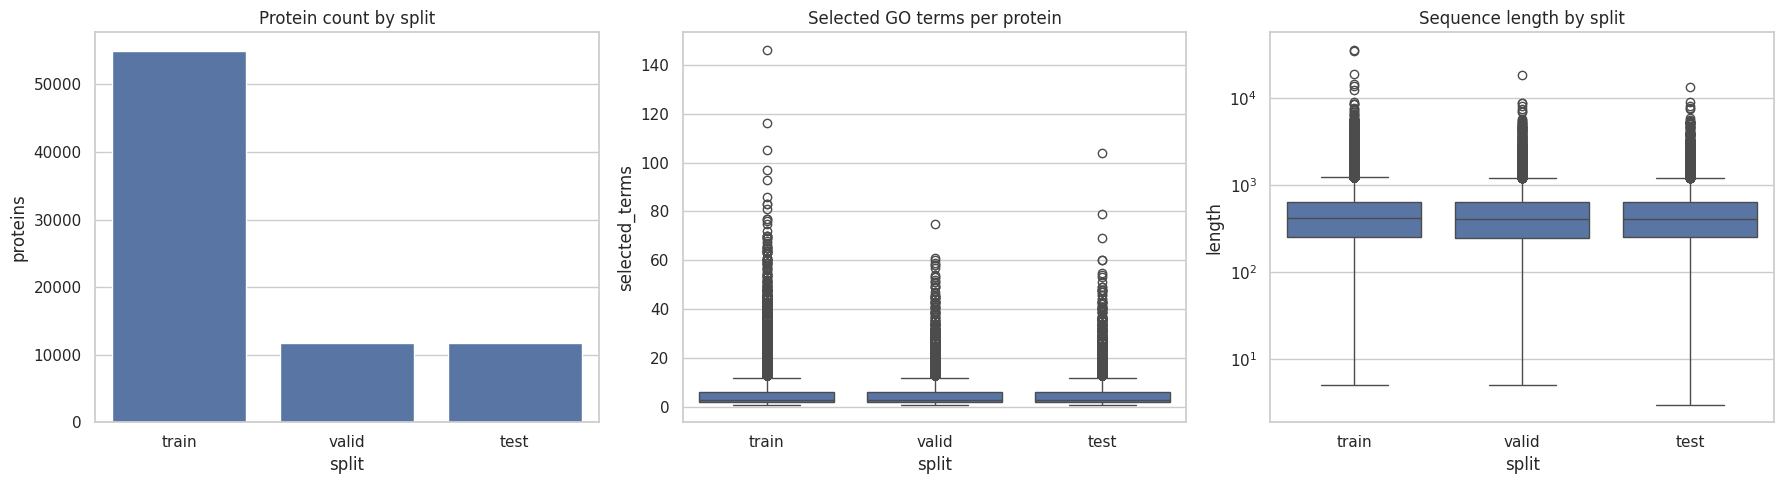

In [7]:
# =============================
# 5. Protein-level train/valid/test split
# =============================
def make_split_strata(ids):
    rows = []
    for pid in ids:
        terms = protein_to_terms_full.get(pid, set())
        aspects = sorted({term_to_aspect.get(t, 'UNK') for t in terms})
        aspect_sig = ''.join(a for a in ['MF', 'BP', 'CC'] if a in aspects) or 'UNK'
        n = len(terms)
        bin_name = 'few' if n <= 3 else 'mid' if n <= 10 else 'many'
        rows.append(f"{aspect_sig}_{bin_name}")
    s = pd.Series(rows, index=ids)
    counts = s.value_counts()
    return s.where(s.map(counts) >= 5, 'rare').loc[ids].values

split_output_dir = Path(CONFIG['artifact_dir']) / 'splits'
split_output_dir.mkdir(parents=True, exist_ok=True)

strata = make_split_strata(usable_ids)
try:
    train_valid_ids, test_ids = train_test_split(
        usable_ids,
        test_size=CONFIG['test_size'],
        random_state=SEED,
        stratify=strata if CONFIG['split_mode'] == 'stratified_protein' else None,
    )
    valid_relative_size = CONFIG['valid_size'] / (1.0 - CONFIG['test_size'])
    train_valid_strata = make_split_strata(train_valid_ids)
    train_ids, valid_ids = train_test_split(
        train_valid_ids,
        test_size=valid_relative_size,
        random_state=SEED,
        stratify=train_valid_strata if CONFIG['split_mode'] == 'stratified_protein' else None,
    )
except ValueError as e:
    print(f"[SPLIT] Stratified split failed: {e}. Falling back to random protein split.")
    train_valid_ids, test_ids = train_test_split(usable_ids, test_size=CONFIG['test_size'], random_state=SEED)
    valid_relative_size = CONFIG['valid_size'] / (1.0 - CONFIG['test_size'])
    train_ids, valid_ids = train_test_split(train_valid_ids, test_size=valid_relative_size, random_state=SEED)

train_ids = sorted(train_ids)
valid_ids = sorted(valid_ids)
test_ids = sorted(test_ids)
assert not set(train_ids).intersection(valid_ids)
assert not set(train_ids).intersection(test_ids)
assert not set(valid_ids).intersection(test_ids)

print(f"[SPLIT] train proteins: {len(train_ids):,} ({len(train_ids)/len(usable_ids):.1%})")
print(f"[SPLIT] valid proteins: {len(valid_ids):,} ({len(valid_ids)/len(usable_ids):.1%})")
print(f"[SPLIT] test proteins : {len(test_ids):,} ({len(test_ids)/len(usable_ids):.1%})")
print(f"[SPLIT] total usable  : {len(usable_ids):,}")

split_id_map = {'train': train_ids, 'valid': valid_ids, 'test': test_ids}
for split_name, ids in split_id_map.items():
    (split_output_dir / f'{split_name}_ids.txt').write_text('\n'.join(ids) + '\n')

split_rows = []
for split_name, ids in split_id_map.items():
    full_counts = [len(protein_to_terms_full.get(p, [])) for p in ids]
    selected_counts = [len(protein_to_terms_selected.get(p, [])) for p in ids]
    aspect_counter = Counter()
    for p in ids:
        aspect_counter.update({term_to_aspect.get(t, 'UNK') for t in protein_to_terms_full.get(p, set())})
    split_rows.append({
        'split': split_name,
        'proteins': len(ids),
        'protein_ratio': len(ids) / len(usable_ids),
        'avg_full_terms_per_protein': float(np.mean(full_counts)),
        'avg_selected_terms_per_protein': float(np.mean(selected_counts)),
        'median_selected_terms_per_protein': float(np.median(selected_counts)),
        'proteins_with_MF': aspect_counter.get('MF', 0),
        'proteins_with_BP': aspect_counter.get('BP', 0),
        'proteins_with_CC': aspect_counter.get('CC', 0),
    })
split_summary = pd.DataFrame(split_rows)
split_summary_path = split_output_dir / 'split_summary.csv'
split_summary.to_csv(split_summary_path, index=False)
display(split_summary)
print('[SPLIT] Wrote downloadable split files:')
for path in [split_output_dir / 'train_ids.txt', split_output_dir / 'valid_ids.txt', split_output_dir / 'test_ids.txt', split_summary_path]:
    print(f"  - {path} ({path.stat().st_size / 1024:.1f} KB)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=split_summary, x='split', y='proteins', ax=axes[0])
axes[0].set_title('Protein count by split')
plot_counts = []
for split_name, ids in split_id_map.items():
    for p in ids:
        plot_counts.append({'split': split_name, 'selected_terms': len(protein_to_terms_selected.get(p, [])), 'length': len(sequences[p])})
plot_counts_df = pd.DataFrame(plot_counts)
sns.boxplot(data=plot_counts_df, x='split', y='selected_terms', ax=axes[1])
axes[1].set_title('Selected GO terms per protein')
sns.boxplot(data=plot_counts_df, x='split', y='length', ax=axes[2])
axes[2].set_title('Sequence length by split')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

[TARGET] Y_train: (54965, 3000), positives=279,161, density=0.00169
[TARGET] Y_valid: (11779, 3000), positives=59,267, density=0.00168
[TARGET] Y_test : (11779, 3000), positives=59,635, density=0.00169
[TARGET] pos_weight range: 1.15 - 30.00
[SEQ] Xseq_train=(54965, 1024), Xseq_valid=(11779, 1024), Xseq_test=(11779, 1024)


,split,positive_labels,density
0,train,279161,0.001693
1,valid,59267,0.001677
2,test,59635,0.001688


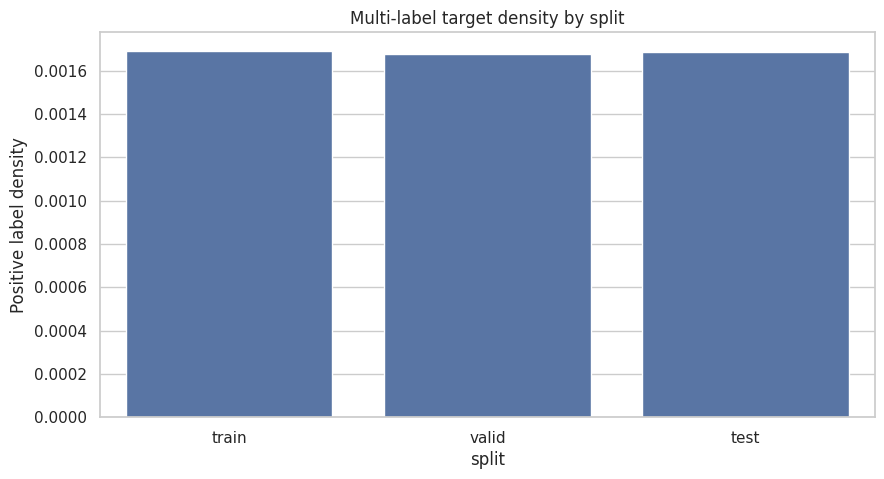

In [8]:
# =============================
# 6. Targets and sequence tensors
# =============================
def build_label_matrix(ids):
    Y = np.zeros((len(ids), len(selected_terms)), dtype=np.float32)
    for i, pid in enumerate(ids):
        for term in protein_to_terms_selected.get(pid, []):
            j = term_to_index.get(term)
            if j is not None:
                Y[i, j] = 1.0
    return Y

Y_train = build_label_matrix(train_ids)
Y_valid = build_label_matrix(valid_ids)
Y_test = build_label_matrix(test_ids)
print(f"[TARGET] Y_train: {Y_train.shape}, positives={int(Y_train.sum()):,}, density={Y_train.mean():.5f}")
print(f"[TARGET] Y_valid: {Y_valid.shape}, positives={int(Y_valid.sum()):,}, density={Y_valid.mean():.5f}")
print(f"[TARGET] Y_test : {Y_test.shape}, positives={int(Y_test.sum()):,}, density={Y_test.mean():.5f}")

pos_counts = Y_train.sum(axis=0)
pos_weight = (Y_train.shape[0] - pos_counts) / np.maximum(pos_counts, 1.0)
pos_weight = np.sqrt(pos_weight)
pos_weight = np.clip(pos_weight, 1.0, CONFIG['pos_weight_clip']).astype(np.float32)
print(f"[TARGET] pos_weight range: {pos_weight.min():.2f} - {pos_weight.max():.2f}")

AA = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_idx = {aa: i + 1 for i, aa in enumerate(AA)}  # 0 = pad/unknown

def encode_sequence(seq, max_len=None):
    if max_len is None:
        max_len = CONFIG['sequence_max_length']
    arr = np.zeros(max_len, dtype=np.int64)
    seq = seq[:max_len]
    for i, aa in enumerate(seq):
        arr[i] = aa_to_idx.get(aa, 0)
    return arr

def build_sequence_matrix(ids):
    X = np.zeros((len(ids), CONFIG['sequence_max_length']), dtype=np.int64)
    for i, pid in enumerate(ids):
        X[i] = encode_sequence(sequences[pid])
    return X

Xseq_train = build_sequence_matrix(train_ids)
Xseq_valid = build_sequence_matrix(valid_ids)
Xseq_test = build_sequence_matrix(test_ids)
print(f"[SEQ] Xseq_train={Xseq_train.shape}, Xseq_valid={Xseq_valid.shape}, Xseq_test={Xseq_test.shape}")

plt.figure(figsize=(10, 5))
label_density_df = pd.DataFrame({
    'split': ['train', 'valid', 'test'],
    'positive_labels': [int(Y_train.sum()), int(Y_valid.sum()), int(Y_test.sum())],
    'density': [Y_train.mean(), Y_valid.mean(), Y_test.mean()],
})
display(label_density_df)
sns.barplot(data=label_density_df, x='split', y='density')
plt.title('Multi-label target density by split')
plt.ylabel('Positive label density')
plt.show()

In [9]:
# =============================
# 7. Protein language model frozen embedding extraction
# =============================
ARTIFACT_DIR = Path(CONFIG['artifact_dir'])
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
EMB_DIR = ARTIFACT_DIR / 'embeddings'
EMB_DIR.mkdir(parents=True, exist_ok=True)

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError as e:
    raise ImportError('Please install transformers on Kaggle/Colab: pip install transformers accelerate') from e


def embedding_cache_filename(split_name, model_name, max_length):
    safe_model = model_name.replace('/', '__')
    return f"{split_name}_{safe_model}_labels{CONFIG['max_labels']}_len{max_length}.npy"


def embedding_cache_path(split_name, model_name, max_length):
    return EMB_DIR / embedding_cache_filename(split_name, model_name, max_length)


def find_existing_embedding_cache(split_name, model_name, max_length):
    filename = embedding_cache_filename(split_name, model_name, max_length)
    candidates = [embedding_cache_path(split_name, model_name, max_length)]
    for root in CONFIG.get('embedding_cache_input_dirs', []):
        candidates.append(Path(root) / 'embeddings' / filename)
        candidates.append(Path(root) / filename)
    if Path('/kaggle/input').exists():
        candidates.extend(Path('/kaggle/input').rglob(filename))
    seen = set()
    for path in candidates:
        path = Path(path)
        if path in seen:
            continue
        seen.add(path)
        if path.exists():
            return path
    return None


def prepare_lm_sequences(batch_seqs, model_name):
    if 'prot_bert' in model_name.lower() or 'protbert' in model_name.lower():
        cleaned = [re.sub(r"[UZOB]", "X", seq) for seq in batch_seqs]
        return [' '.join(list(seq)) for seq in cleaned]
    return batch_seqs


def pool_lm_outputs(outputs, attention_mask):
    hidden = outputs.last_hidden_state
    mask = attention_mask.unsqueeze(-1).to(hidden.dtype)
    if CONFIG['embedding_pooling'] == 'cls':
        pooled = hidden[:, 0]
    else:
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
    return pooled


def extract_lm_embeddings(ids, split_name, model_name, batch_size, max_length, log_prefix):
    cache_path = embedding_cache_path(split_name, model_name, max_length)
    existing_cache = None if CONFIG['recompute_embeddings'] else find_existing_embedding_cache(split_name, model_name, max_length)
    if existing_cache is not None:
        print(f"[{log_prefix}] Loading cached {split_name} embeddings: {existing_cache}")
        X = np.load(existing_cache)
        if existing_cache != cache_path:
            np.save(cache_path, X)
            print(f"[{log_prefix}] Copied cache into working artifacts: {cache_path}")
        return X

    print(f"[{log_prefix}] Loading tokenizer/model: {model_name}")
    tokenizer_kwargs = {'do_lower_case': False} if 'prot_bert' in model_name.lower() or 'protbert' in model_name.lower() else {}
    tokenizer = AutoTokenizer.from_pretrained(model_name, **tokenizer_kwargs)
    lm = AutoModel.from_pretrained(model_name).to(DEVICE)
    lm.eval()
    if DEVICE == 'cuda' and CONFIG['use_fp16_embeddings']:
        lm.half()

    vectors = []
    start = time.time()
    for start_idx in range(0, len(ids), batch_size):
        batch_ids = ids[start_idx:start_idx + batch_size]
        batch_seqs = [sequences[pid][:max_length] for pid in batch_ids]
        batch_seqs = prepare_lm_sequences(batch_seqs, model_name)
        toks = tokenizer(batch_seqs, return_tensors='pt', padding=True, truncation=True, max_length=max_length)
        toks = {k: v.to(DEVICE) for k, v in toks.items()}
        with torch.no_grad():
            if DEVICE == 'cuda':
                with torch.cuda.amp.autocast(enabled=CONFIG['use_fp16_embeddings']):
                    outputs = lm(**toks)
                    pooled = pool_lm_outputs(outputs, toks['attention_mask'])
            else:
                outputs = lm(**toks)
                pooled = pool_lm_outputs(outputs, toks['attention_mask'])
        vectors.append(pooled.float().cpu().numpy())
        if (start_idx // batch_size + 1) % 50 == 0:
            done = min(start_idx + batch_size, len(ids))
            print(f"[{log_prefix}] {split_name}: {done:,}/{len(ids):,} proteins | elapsed {(time.time() - start)/60:.1f} min")
    X = np.vstack(vectors).astype(np.float32)
    np.save(cache_path, X)
    print(f"[{log_prefix}] Saved {split_name} embeddings: {cache_path} | shape={X.shape}")
    del lm
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return X

Xesm_train = extract_lm_embeddings(train_ids, 'train', CONFIG['embedding_model_name'], CONFIG['embedding_batch_size'], CONFIG['embedding_max_length'], 'ESM')
Xesm_valid = extract_lm_embeddings(valid_ids, 'valid', CONFIG['embedding_model_name'], CONFIG['embedding_batch_size'], CONFIG['embedding_max_length'], 'ESM')
Xesm_test = extract_lm_embeddings(test_ids, 'test', CONFIG['embedding_model_name'], CONFIG['embedding_batch_size'], CONFIG['embedding_max_length'], 'ESM')
print(f"[ESM] Xesm_train={Xesm_train.shape}, Xesm_valid={Xesm_valid.shape}, Xesm_test={Xesm_test.shape}")

if CONFIG['train_protbert']:
    Xprotbert_train = extract_lm_embeddings(train_ids, 'train', CONFIG['protbert_model_name'], CONFIG['protbert_batch_size'], CONFIG['protbert_max_length'], 'PROTBERT')
    Xprotbert_valid = extract_lm_embeddings(valid_ids, 'valid', CONFIG['protbert_model_name'], CONFIG['protbert_batch_size'], CONFIG['protbert_max_length'], 'PROTBERT')
    Xprotbert_test = extract_lm_embeddings(test_ids, 'test', CONFIG['protbert_model_name'], CONFIG['protbert_batch_size'], CONFIG['protbert_max_length'], 'PROTBERT')
    print(f"[PROTBERT] Xprotbert_train={Xprotbert_train.shape}, Xprotbert_valid={Xprotbert_valid.shape}, Xprotbert_test={Xprotbert_test.shape}")
else:
    Xprotbert_train = None
    Xprotbert_valid = None
    Xprotbert_test = None
    print('[PROTBERT] disabled by CONFIG; set train_protbert=True to add this ensemble branch')

[ESM] Loading cached train embeddings: /kaggle/input/notebooks/qundngdngminhqun/cafa6-offline-realtime-solution/cafa6_high_performance_artifacts/embeddings/train_facebook__esm2_t30_150M_UR50D_labels3000_len1022.npy
[ESM] Copied cache into working artifacts: /kaggle/working/cafa6_high_performance_artifacts/embeddings/train_facebook__esm2_t30_150M_UR50D_labels3000_len1022.npy
[ESM] Loading cached valid embeddings: /kaggle/input/notebooks/qundngdngminhqun/cafa6-offline-realtime-solution/cafa6_high_performance_artifacts/embeddings/valid_facebook__esm2_t30_150M_UR50D_labels3000_len1022.npy
[ESM] Copied cache into working artifacts: /kaggle/working/cafa6_high_performance_artifacts/embeddings/valid_facebook__esm2_t30_150M_UR50D_labels3000_len1022.npy
[ESM] Loading cached test embeddings: /kaggle/input/notebooks/qundngdngminhqun/cafa6-offline-realtime-solution/cafa6_high_performance_artifacts/embeddings/test_facebook__esm2_t30_150M_UR50D_labels3000_len1022.npy
[ESM] Copied cache into working a

In [10]:
# =============================
# 8. Model architectures: ESM-MLP, ProtCNN, BiLSTM-Attention
# =============================
class EmbeddingMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=(1024, 512), dropout=0.35):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class ProtCNN(nn.Module):
    def __init__(self, output_dim, vocab_size=21, emb_dim=128, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.conv3 = nn.Sequential(nn.Conv1d(emb_dim, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU())
        self.conv5 = nn.Sequential(nn.Conv1d(emb_dim, 256, 5, padding=2), nn.BatchNorm1d(256), nn.ReLU())
        self.conv7 = nn.Sequential(nn.Conv1d(emb_dim, 256, 7, padding=3), nn.BatchNorm1d(256), nn.ReLU())
        self.conv = nn.Sequential(
            nn.Conv1d(768, 512, 3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, output_dim),
        )
    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)
        x = torch.cat([self.conv3(x), self.conv5(x), self.conv7(x)], dim=1)
        x = self.conv(x)
        gap = torch.mean(x, dim=2)
        gmp = torch.max(x, dim=2).values
        return self.head(torch.cat([gap, gmp], dim=1))

class BiLSTMAttention(nn.Module):
    def __init__(self, output_dim, vocab_size=21, emb_dim=128, hidden=256, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm1 = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.attn = nn.MultiheadAttention(hidden * 2, num_heads=8, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden * 2)
        self.lstm2 = nn.LSTM(hidden * 2, hidden // 2, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, output_dim),
        )
    def forward(self, x):
        pad_mask = x.eq(0)
        x = self.embedding(x)
        x, _ = self.lstm1(x)
        attn_out, _ = self.attn(x, x, x, key_padding_mask=pad_mask)
        x = self.norm(x + self.dropout(attn_out))
        x, _ = self.lstm2(x)
        valid = (~pad_mask).unsqueeze(-1).to(x.dtype)
        gap = (x * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1.0)
        masked = x.masked_fill(pad_mask.unsqueeze(-1), -1e4)
        gmp = masked.max(dim=1).values
        return self.head(torch.cat([gap, gmp], dim=1))

print('[MODEL] Architectures ready')

[MODEL] Architectures ready


In [11]:
# =============================
# 9. Training and evaluation utilities
# =============================
def basic_metrics(y_true, y_prob, threshold=0.2):
    y_pred = (y_prob >= threshold).astype(np.uint8)
    return {
        'threshold': threshold,
        'micro_f1': f1_score(y_true.ravel(), y_pred.ravel(), zero_division=0),
        'micro_precision': precision_score(y_true.ravel(), y_pred.ravel(), zero_division=0),
        'micro_recall': recall_score(y_true.ravel(), y_pred.ravel(), zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'avg_pred_terms': float(y_pred.sum(axis=1).mean()),
    }

def precision_recall_at_k(y_true, y_prob, k):
    k = min(k, y_prob.shape[1])
    top_idx = np.argpartition(-y_prob, kth=k-1, axis=1)[:, :k]
    hits = np.take_along_axis(y_true, top_idx, axis=1).sum(axis=1)
    true_counts = np.maximum(y_true.sum(axis=1), 1)
    return {f'precision@{k}': float(np.mean(hits / k)), f'recall@{k}': float(np.mean(hits / true_counts))}

@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    chunks = []
    for xb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        chunks.append(torch.sigmoid(logits).cpu().numpy().astype(np.float32))
    return np.vstack(chunks)

def train_model(model, train_loader, valid_loader, y_valid, model_name, epochs):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.from_numpy(pos_weight).to(DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
    best_state = None
    best_f1 = -1.0
    bad_epochs = 0
    history = []
    start = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        epoch_start = time.time()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            losses.append(loss.item())
        y_prob_valid = predict_proba(model, valid_loader)
        metrics = basic_metrics(y_valid, y_prob_valid, threshold=0.10)
        metrics.update({'model': model_name, 'epoch': epoch, 'train_loss': float(np.mean(losses)), 'lr': optimizer.param_groups[0]['lr'], 'epoch_seconds': time.time() - epoch_start})
        history.append(metrics)
        scheduler.step(metrics['micro_f1'])
        print(f"[TRAIN:{model_name}] epoch={epoch:02d} loss={metrics['train_loss']:.4f} valid_micro_f1@0.10={metrics['micro_f1']:.4f} P={metrics['micro_precision']:.4f} R={metrics['micro_recall']:.4f} avg_terms={metrics['avg_pred_terms']:.1f} time={metrics['epoch_seconds']:.1f}s")
        if metrics['micro_f1'] > best_f1:
            best_f1 = metrics['micro_f1']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
            print(f"[TRAIN:{model_name}] new best valid_micro_f1@0.10={best_f1:.4f}")
        else:
            bad_epochs += 1
            if bad_epochs >= CONFIG['early_stopping_patience']:
                print(f"[TRAIN:{model_name}] early stopping")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"[TRAIN:{model_name}] elapsed={(time.time() - start)/60:.1f} min")
    return model, pd.DataFrame(history)

def tune_thresholds(y_true, y_prob, name, split_name):
    rows = []
    for th in CONFIG['threshold_grid']:
        row = basic_metrics(y_true, y_prob, threshold=th)
        row['model'] = name
        row['split'] = split_name
        for k in CONFIG['precision_k_values']:
            row.update(precision_recall_at_k(y_true, y_prob, k))
        rows.append(row)
    df = pd.DataFrame(rows)
    best = df.iloc[df['micro_f1'].idxmax()]
    print(f"[EVAL:{name}:{split_name}] best_threshold={best['threshold']:.3f} micro_f1={best['micro_f1']:.4f} P={best['micro_precision']:.4f} R={best['micro_recall']:.4f}")
    return df, float(best['threshold'])

In [12]:
# =============================
# 10. Train ESM-MLP, ProtCNN, BiLSTM and ensemble
# =============================
predictions_valid = {}
predictions_test = {}
histories = []
threshold_tables = []
model_states = {}
BRANCH_CKPT_DIR = ARTIFACT_DIR / 'branch_checkpoints'
BRANCH_CKPT_DIR.mkdir(parents=True, exist_ok=True)

def save_branch_checkpoint(branch_name, state_dict):
    path = BRANCH_CKPT_DIR / f'{branch_name}.pt'
    torch.save({
        'branch': branch_name,
        'state_dict': state_dict,
        'config': CONFIG,
        'selected_terms': selected_terms,
        'active_weights_so_far': {k: CONFIG['ensemble_weights'].get(k, 1.0) for k in model_states},
    }, path)
    print(f'[CHECKPOINT] saved {branch_name}: {path} ({path.stat().st_size / 1024 / 1024:.1f} MB)')

def make_tensor_loader(X, Y, batch_size, shuffle):
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(Y)),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE == 'cuda'),
    )

if CONFIG['train_esm_mlp']:
    print('\n[PIPELINE] Training ESM-MLP classifier')
    train_loader = make_tensor_loader(Xesm_train, Y_train, CONFIG['esm_batch_size'], True)
    valid_loader = make_tensor_loader(Xesm_valid, Y_valid, CONFIG['esm_batch_size'], False)
    test_loader = make_tensor_loader(Xesm_test, Y_test, CONFIG['esm_batch_size'], False)
    esm_mlp = EmbeddingMLP(Xesm_train.shape[1], Y_train.shape[1], CONFIG['esm_hidden_dims'], CONFIG['esm_dropout'])
    esm_mlp, hist = train_model(esm_mlp, train_loader, valid_loader, Y_valid, 'esm_mlp', CONFIG['esm_epochs'])
    histories.append(hist)
    predictions_valid['esm_mlp'] = predict_proba(esm_mlp, valid_loader)
    predictions_test['esm_mlp'] = predict_proba(esm_mlp, test_loader)
    threshold_tables.append(tune_thresholds(Y_valid, predictions_valid['esm_mlp'], 'esm_mlp', 'valid')[0])
    model_states['esm_mlp'] = {k: v.cpu() for k, v in esm_mlp.state_dict().items()}
    save_branch_checkpoint('esm_mlp', model_states['esm_mlp'])
    del esm_mlp
    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

if CONFIG['train_protbert'] and Xprotbert_train is not None:
    print('\n[PIPELINE] Training ProtBERT-MLP classifier')
    train_loader = make_tensor_loader(Xprotbert_train, Y_train, CONFIG['esm_batch_size'], True)
    valid_loader = make_tensor_loader(Xprotbert_valid, Y_valid, CONFIG['esm_batch_size'], False)
    test_loader = make_tensor_loader(Xprotbert_test, Y_test, CONFIG['esm_batch_size'], False)
    protbert_mlp = EmbeddingMLP(Xprotbert_train.shape[1], Y_train.shape[1], CONFIG['esm_hidden_dims'], CONFIG['esm_dropout'])
    protbert_mlp, hist = train_model(protbert_mlp, train_loader, valid_loader, Y_valid, 'protbert_mlp', CONFIG['esm_epochs'])
    histories.append(hist)
    predictions_valid['protbert_mlp'] = predict_proba(protbert_mlp, valid_loader)
    predictions_test['protbert_mlp'] = predict_proba(protbert_mlp, test_loader)
    threshold_tables.append(tune_thresholds(Y_valid, predictions_valid['protbert_mlp'], 'protbert_mlp', 'valid')[0])
    model_states['protbert_mlp'] = {k: v.cpu() for k, v in protbert_mlp.state_dict().items()}
    save_branch_checkpoint('protbert_mlp', model_states['protbert_mlp'])
    del protbert_mlp
    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

if CONFIG['train_protcnn']:
    print('\n[PIPELINE] Training ProtCNN')
    train_loader = make_tensor_loader(Xseq_train, Y_train, CONFIG['sequence_batch_size'], True)
    valid_loader = make_tensor_loader(Xseq_valid, Y_valid, CONFIG['sequence_batch_size'], False)
    test_loader = make_tensor_loader(Xseq_test, Y_test, CONFIG['sequence_batch_size'], False)
    protcnn = ProtCNN(Y_train.shape[1], dropout=CONFIG['protcnn_dropout'])
    protcnn, hist = train_model(protcnn, train_loader, valid_loader, Y_valid, 'protcnn', CONFIG['protcnn_epochs'])
    histories.append(hist)
    predictions_valid['protcnn'] = predict_proba(protcnn, valid_loader)
    predictions_test['protcnn'] = predict_proba(protcnn, test_loader)
    threshold_tables.append(tune_thresholds(Y_valid, predictions_valid['protcnn'], 'protcnn', 'valid')[0])
    model_states['protcnn'] = {k: v.cpu() for k, v in protcnn.state_dict().items()}
    save_branch_checkpoint('protcnn', model_states['protcnn'])
    del protcnn
    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

if CONFIG['train_bilstm_attention']:
    print('\n[PIPELINE] Training BiLSTM-Attention')
    seq_bs = max(32, CONFIG['sequence_batch_size'] // 4)
    train_loader = make_tensor_loader(Xseq_train, Y_train, seq_bs, True)
    valid_loader = make_tensor_loader(Xseq_valid, Y_valid, seq_bs, False)
    test_loader = make_tensor_loader(Xseq_test, Y_test, seq_bs, False)
    bilstm = BiLSTMAttention(Y_train.shape[1], dropout=CONFIG['bilstm_dropout'])
    bilstm, hist = train_model(bilstm, train_loader, valid_loader, Y_valid, 'bilstm_attention', CONFIG['bilstm_epochs'])
    histories.append(hist)
    predictions_valid['bilstm_attention'] = predict_proba(bilstm, valid_loader)
    predictions_test['bilstm_attention'] = predict_proba(bilstm, test_loader)
    threshold_tables.append(tune_thresholds(Y_valid, predictions_valid['bilstm_attention'], 'bilstm_attention', 'valid')[0])
    model_states['bilstm_attention'] = {k: v.cpu() for k, v in bilstm.state_dict().items()}
    save_branch_checkpoint('bilstm_attention', model_states['bilstm_attention'])
    del bilstm
    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

# Weighted ensemble over enabled models. Weights are tuned only by config and normalized over active branches.
active_weights = {k: CONFIG['ensemble_weights'].get(k, 1.0) for k in predictions_valid}
weight_sum = sum(active_weights.values())
active_weights = {k: v / weight_sum for k, v in active_weights.items()}
y_prob_valid = sum(active_weights[k] * predictions_valid[k] for k in predictions_valid)
y_prob_test = sum(active_weights[k] * predictions_test[k] for k in predictions_test)
print(f"[ENSEMBLE] active weights: {active_weights}")
threshold_tables.append(tune_thresholds(Y_valid, y_prob_valid, 'ensemble', 'valid')[0])

history_df = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
threshold_df = pd.concat(threshold_tables, ignore_index=True)
ensemble_valid_df = threshold_df[(threshold_df['model'] == 'ensemble') & (threshold_df['split'] == 'valid')]
best_row = ensemble_valid_df.loc[ensemble_valid_df['micro_f1'].idxmax()].to_dict()
best_threshold = float(best_row['threshold'])
print(f"[ENSEMBLE] best validation threshold by micro F1: {best_threshold:.3f}")

test_metrics_at_best = basic_metrics(Y_test, y_prob_test, threshold=best_threshold)
test_metrics_at_best.update({'model': 'ensemble', 'split': 'test', 'selected_by': 'valid_best_threshold'})
for k in CONFIG['precision_k_values']:
    test_metrics_at_best.update(precision_recall_at_k(Y_test, y_prob_test, k))
final_test_metrics_df = pd.DataFrame([test_metrics_at_best])
print('[TEST] Final held-out test metrics at validation-selected threshold:')
display(final_test_metrics_df)
display(threshold_df.sort_values(['model', 'split', 'threshold']))


[PIPELINE] Training ESM-MLP classifier
[TRAIN:esm_mlp] epoch=01 loss=0.1564 valid_micro_f1@0.10=0.0477 P=0.0249 R=0.5743 avg_terms=116.1 time=15.4s
[TRAIN:esm_mlp] new best valid_micro_f1@0.10=0.0477
[TRAIN:esm_mlp] epoch=02 loss=0.0978 valid_micro_f1@0.10=0.0456 P=0.0236 R=0.6557 avg_terms=139.8 time=14.7s
[TRAIN:esm_mlp] epoch=03 loss=0.0892 valid_micro_f1@0.10=0.0361 P=0.0185 R=0.7322 avg_terms=198.9 time=15.0s
[TRAIN:esm_mlp] epoch=04 loss=0.0828 valid_micro_f1@0.10=0.0427 P=0.0220 R=0.7339 avg_terms=168.1 time=14.7s
[TRAIN:esm_mlp] early stopping
[TRAIN:esm_mlp] elapsed=1.0 min
[EVAL:esm_mlp:valid] best_threshold=0.400 micro_f1=0.2296 P=0.2534 R=0.2098
[CHECKPOINT] saved esm_mlp: /kaggle/working/cafa6_high_performance_artifacts/branch_checkpoints/esm_mlp.pt (10.5 MB)

[PIPELINE] Training ProtCNN
[TRAIN:protcnn] epoch=01 loss=0.1333 valid_micro_f1@0.10=0.0362 P=0.0188 R=0.4509 avg_terms=120.4 time=274.4s
[TRAIN:protcnn] new best valid_micro_f1@0.10=0.0362
[TRAIN:protcnn] epoch=02 

,threshold,micro_f1,micro_precision,micro_recall,macro_f1,avg_pred_terms,model,split,selected_by,precision@10,recall@10,precision@25,recall@25,precision@50,recall@50,precision@100,recall@100,precision@250,recall@250
0,0.3,0.251136,0.252108,0.250172,0.008887,5.023941,ensemble,test,valid_best_threshold,0.158613,0.419331,0.080791,0.503289,0.047462,0.568219,0.027853,0.639423,0.013556,0.740801


,threshold,micro_f1,micro_precision,micro_recall,macro_f1,avg_pred_terms,model,split,precision@10,recall@10,precision@25,recall@25,precision@50,recall@50,precision@100,recall@100,precision@250,recall@250
22,0.01,0.005640,0.002829,0.918066,0.004150,1632.881654,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
23,0.02,0.009205,0.004629,0.794692,0.004710,863.784447,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
24,0.03,0.013766,0.006951,0.696711,0.004777,504.293828,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
25,0.05,0.025933,0.013273,0.560936,0.004753,212.636726,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
26,0.07,0.043100,0.022586,0.470042,0.004341,104.715596,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
27,0.10,0.077582,0.043157,0.383417,0.003715,44.701672,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
28,0.15,0.136702,0.088387,0.301517,0.003146,17.164275,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
29,0.20,0.177236,0.138628,0.245651,0.002344,8.916037,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
30,0.30,0.196834,0.228348,0.172963,0.001593,3.811189,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982
31,0.40,0.157278,0.325563,0.103683,0.000829,1.602428,bilstm_attention,valid,0.127821,0.340053,0.066746,0.421589,0.039362,0.482660,0.023242,0.551572,0.011583,0.652982


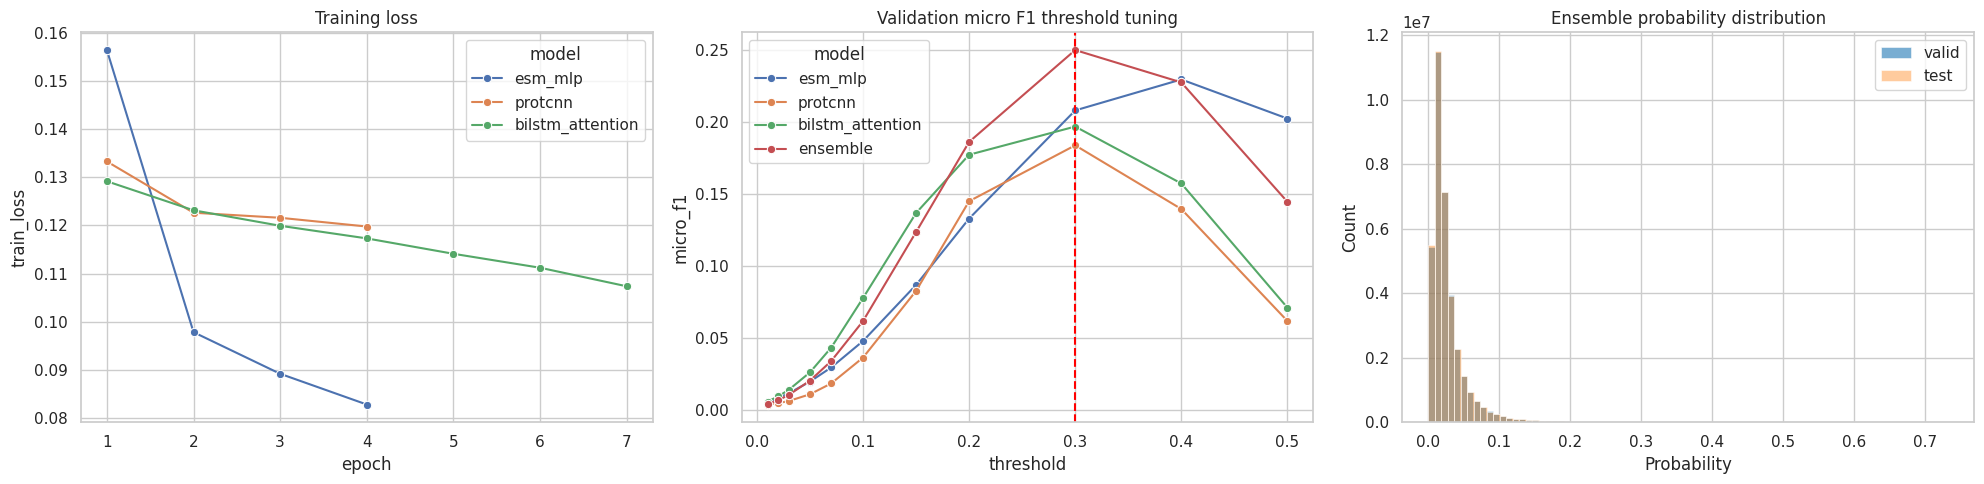

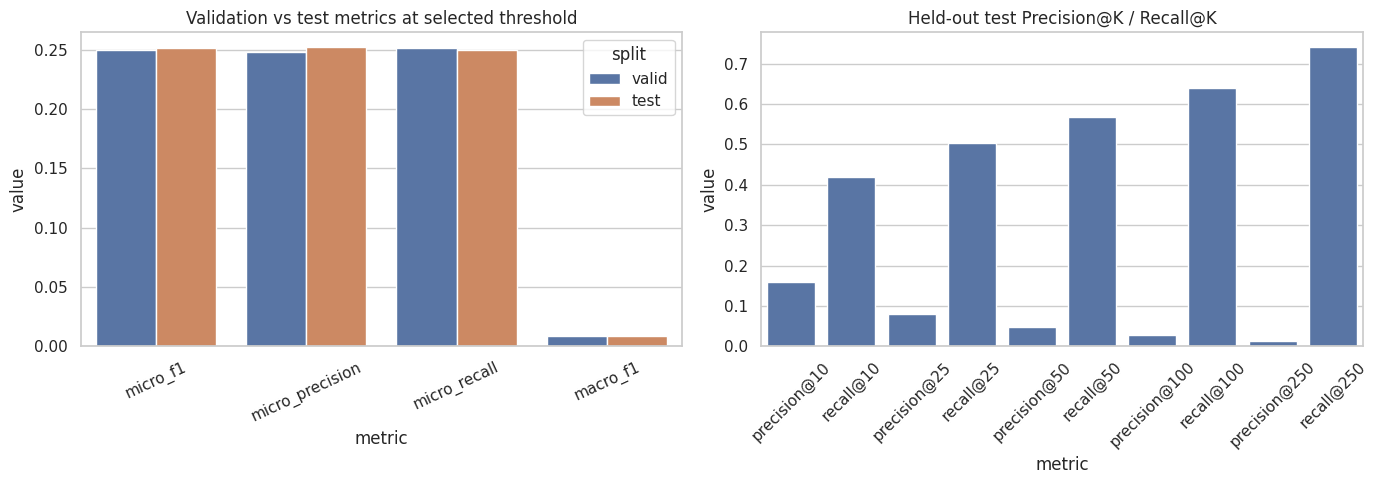

[PRED] Test protein: A0A026W182 | length=478 | true_full_terms=7
[PRED] True selected terms: ['GO:0004984', 'GO:0035176', 'GO:0042048', 'GO:0050911']


,GO_Term,Aspect,Name,Score,Train_Frequency,IA
0,GO:0005886,C,plasma membrane,0.581814,10150,0.033008
1,GO:0005783,C,endoplasmic reticulum,0.346567,2837,1.094174
2,GO:0005515,F,protein binding,0.338674,33713,0.201153
3,GO:0016324,C,apical plasma membrane,0.312620,643,0.065363
4,GO:0005789,C,endoplasmic reticulum membrane,0.299584,1351,0.000893
5,GO:0016020,C,membrane,0.299581,3563,1.595692
6,GO:0005794,C,Golgi apparatus,0.282747,2045,1.610668
7,GO:0007186,P,G protein-coupled receptor signaling pathway,0.215987,569,2.452060
8,GO:0005768,C,endosome,0.211231,672,1.003279
9,GO:0016323,C,basolateral plasma membrane,0.208308,377,0.238657


[PRED] Test protein: A0A061IR73 | length=980 | true_full_terms=1
[PRED] True selected terms: ['GO:0016558']


,GO_Term,Aspect,Name,Score,Train_Frequency,IA
0,GO:0005515,F,protein binding,0.574358,33713,0.201153
1,GO:0005829,C,cytosol,0.464096,13040,1.426144
2,GO:0005654,C,nucleoplasm,0.400421,5065,0.364537
3,GO:0005737,C,cytoplasm,0.361840,9442,0.344108
4,GO:0005739,C,mitochondrion,0.315216,5807,2.027294
5,GO:0005634,C,nucleus,0.307001,13283,0.953496
6,GO:0003723,F,RNA binding,0.213336,1613,1.242565
7,GO:0042802,F,identical protein binding,0.212279,3547,2.997305
8,GO:0005524,F,ATP binding,0.206102,713,0.004036
9,GO:0016020,C,membrane,0.205022,3563,1.595692


[PRED] Test protein: A0A067XH53 | length=533 | true_full_terms=2
[PRED] True selected terms: ['GO:0009507', 'GO:0010597']


,GO_Term,Aspect,Name,Score,Train_Frequency,IA
0,GO:0005739,C,mitochondrion,0.514439,5807,2.027294
1,GO:0009507,C,chloroplast,0.453820,1512,0.514731
2,GO:0009570,C,chloroplast stroma,0.354779,564,0.002171
3,GO:0009536,C,plastid,0.323067,1080,3.353187
4,GO:0005829,C,cytosol,0.294299,13040,1.426144
5,GO:0009941,C,chloroplast envelope,0.272084,475,0.476352
6,GO:0005515,F,protein binding,0.260931,33713,0.201153
7,GO:0005777,C,peroxisome,0.220272,571,0.006241
8,GO:0005743,C,mitochondrial inner membrane,0.213591,1085,0.002437
9,GO:0005737,C,cytoplasm,0.204497,9442,0.344108


In [13]:
# =============================
# 11. Curves, diagnostics and prediction inspection
# =============================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
if len(history_df):
    sns.lineplot(data=history_df, x='epoch', y='train_loss', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Training loss')

sns.lineplot(data=threshold_df, x='threshold', y='micro_f1', hue='model', marker='o', ax=axes[1])
axes[1].axvline(best_threshold, color='red', linestyle='--', label=f'valid best={best_threshold:.2f}')
axes[1].set_title('Validation micro F1 threshold tuning')

sns.histplot(y_prob_valid.ravel(), bins=80, ax=axes[2], color='tab:blue', alpha=0.6, label='valid')
sns.histplot(y_prob_test.ravel(), bins=80, ax=axes[2], color='tab:orange', alpha=0.4, label='test')
axes[2].set_title('Ensemble probability distribution')
axes[2].set_xlabel('Probability')
axes[2].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metric_cols = ['micro_f1', 'micro_precision', 'micro_recall', 'macro_f1']
valid_best_metrics = threshold_df[(threshold_df['model'] == 'ensemble') & (threshold_df['threshold'] == best_threshold)].iloc[0]
compare_df = pd.DataFrame([
    {'split': 'valid', **{c: valid_best_metrics[c] for c in metric_cols}},
    {'split': 'test', **{c: test_metrics_at_best[c] for c in metric_cols}},
])
compare_melt = compare_df.melt(id_vars='split', value_vars=metric_cols, var_name='metric', value_name='value')
sns.barplot(data=compare_melt, x='metric', y='value', hue='split', ax=axes[0])
axes[0].set_title('Validation vs test metrics at selected threshold')
axes[0].tick_params(axis='x', rotation=25)

pk_cols = [c for c in final_test_metrics_df.columns if c.startswith('precision@') or c.startswith('recall@')]
pk_df = final_test_metrics_df[pk_cols].T.reset_index()
pk_df.columns = ['metric', 'value']
sns.barplot(data=pk_df, x='metric', y='value', ax=axes[1])
axes[1].set_title('Held-out test Precision@K / Recall@K')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


def top_predictions_for_row(row_probs, top_k=20):
    idx = np.argsort(-row_probs)[:top_k]
    rows = []
    for j in idx:
        term = selected_terms[j]
        rows.append({
            'GO_Term': term,
            'Aspect': term_to_aspect.get(term),
            'Name': go_name.get(term, ''),
            'Score': float(row_probs[j]),
            'Train_Frequency': int(label_counts.get(term, 0)),
            'IA': ia(term),
        })
    return pd.DataFrame(rows)

for sample_i in range(min(3, len(test_ids))):
    pid = test_ids[sample_i]
    print('=' * 90)
    print(f"[PRED] Test protein: {pid} | length={len(sequences[pid])} | true_full_terms={len(protein_to_terms_full.get(pid, []))}")
    true_selected = sorted(set(protein_to_terms_full.get(pid, set())).intersection(selected_term_set))
    print(f"[PRED] True selected terms: {true_selected[:25]}{' ...' if len(true_selected) > 25 else ''}")
    display(top_predictions_for_row(y_prob_test[sample_i], top_k=20))

In [14]:
# =============================
# 12. Save artifacts, split outputs and official evaluator inputs
# =============================
model_path = ARTIFACT_DIR / 'cafa6_high_performance_models.pt'
config_path = ARTIFACT_DIR / 'config.json'
terms_path = ARTIFACT_DIR / 'go_terms.json'
go_meta_path = ARTIFACT_DIR / 'go_metadata.json'
history_path = ARTIFACT_DIR / 'training_history.csv'
threshold_path = ARTIFACT_DIR / 'threshold_tuning.csv'
final_metrics_path = ARTIFACT_DIR / 'final_test_metrics.csv'

save_config = dict(CONFIG)
save_config.update({
    'output_dim': int(Y_train.shape[1]),
    'esm_embedding_dim': int(Xesm_train.shape[1]),
    'best_threshold_micro_f1': best_threshold,
    'active_ensemble_weights': active_weights,
    'device_trained_on': DEVICE,
    'split_counts': {'train': len(train_ids), 'valid': len(valid_ids), 'test': len(test_ids)},
})

torch.save({'model_states': model_states, 'config': save_config}, model_path)
with open(config_path, 'w') as f:
    json.dump(save_config, f, indent=2)
with open(terms_path, 'w') as f:
    json.dump(selected_terms, f, indent=2)
with open(go_meta_path, 'w') as f:
    json.dump({
        'term_to_aspect': {t: term_to_aspect.get(t) for t in selected_terms},
        'term_name': {t: go_name.get(t, '') for t in selected_terms},
        'ia': {t: ia(t) for t in selected_terms},
        'parents': {t: sorted(go_parents.get(t, [])) for t in selected_terms},
    }, f, indent=2)
if len(history_df):
    history_df.to_csv(history_path, index=False)
threshold_df.to_csv(threshold_path, index=False)
final_test_metrics_df.to_csv(final_metrics_path, index=False)

# Save dense prediction matrices for reproducibility/debugging.
np.save(ARTIFACT_DIR / 'valid_ensemble_probabilities.npy', y_prob_valid.astype(np.float32))
np.save(ARTIFACT_DIR / 'test_ensemble_probabilities.npy', y_prob_test.astype(np.float32))

# Official CAFA-evaluator-PK inputs for the held-out test split.
official_eval_dir = ARTIFACT_DIR / 'official_eval'
official_pred_dir = official_eval_dir / 'predictions'
official_valid_pred_dir = official_eval_dir / 'predictions_valid'
official_pred_dir.mkdir(parents=True, exist_ok=True)
official_valid_pred_dir.mkdir(parents=True, exist_ok=True)
(test_ids_path := official_eval_dir / 'test_ids.txt').write_text('\n'.join(test_ids) + '\n')
(valid_ids_path := official_eval_dir / 'valid_ids.txt').write_text('\n'.join(valid_ids) + '\n')
(train_ids_path := official_eval_dir / 'train_ids.txt').write_text('\n'.join(train_ids) + '\n')
(terms_of_interest_path := official_eval_dir / 'terms_of_interest.tsv').write_text('\n'.join(selected_terms) + '\n')

gt_rows = []
for pid in test_ids:
    for term in sorted(set(protein_to_terms_full.get(pid, set())).intersection(selected_term_set)):
        gt_rows.append((pid, term))
ground_truth_path = official_eval_dir / 'ground_truth.tsv'
pd.DataFrame(gt_rows).to_csv(ground_truth_path, sep='\t', header=False, index=False)

valid_gt_rows = []
for pid in valid_ids:
    for term in sorted(set(protein_to_terms_full.get(pid, set())).intersection(selected_term_set)):
        valid_gt_rows.append((pid, term))
valid_ground_truth_path = official_eval_dir / 'valid_ground_truth.tsv'
pd.DataFrame(valid_gt_rows).to_csv(valid_ground_truth_path, sep='\t', header=False, index=False)

def write_prediction_tsv(ids, probs, output_path):
    rows = []
    for i, pid in enumerate(ids):
        order = np.argsort(-probs[i])[:CONFIG['official_eval_top_k']]
        for j in order:
            score = float(probs[i, j])
            if score > 0:
                rows.append((pid, selected_terms[j], min(score, 1.0)))
    pd.DataFrame(rows).to_csv(output_path, sep='\t', header=False, index=False)
    return len(rows)

official_prediction_path = official_pred_dir / 'ensemble.tsv'
valid_prediction_path = official_valid_pred_dir / 'ensemble_valid.tsv'
test_pred_rows = write_prediction_tsv(test_ids, y_prob_test, official_prediction_path)
valid_pred_rows = write_prediction_tsv(valid_ids, y_prob_valid, valid_prediction_path)

print('[SAVE] Artifacts and downloadable split/evaluation files saved:')
for pth in [
    model_path, config_path, terms_path, go_meta_path, history_path, threshold_path, final_metrics_path,
    split_output_dir / 'train_ids.txt', split_output_dir / 'valid_ids.txt', split_output_dir / 'test_ids.txt', split_output_dir / 'split_summary.csv',
    train_ids_path, valid_ids_path, test_ids_path, terms_of_interest_path, valid_ground_truth_path, ground_truth_path,
    valid_prediction_path, official_prediction_path,
    ARTIFACT_DIR / 'valid_ensemble_probabilities.npy', ARTIFACT_DIR / 'test_ensemble_probabilities.npy',
]:
    if pth.exists():
        print(f"  - {pth} ({pth.stat().st_size / 1024:.1f} KB)")
print(f"[SAVE] valid prediction rows: {valid_pred_rows:,}")
print(f"[SAVE] test prediction rows : {test_pred_rows:,}")
print('[SAVE] Run official CAFA-evaluator-PK on test split with scripts/run_cafa_pk_eval.py; see docs/cafa6_evaluation_vi.md')

[SAVE] Artifacts and downloadable split/evaluation files saved:
  - /kaggle/working/cafa6_high_performance_artifacts/cafa6_high_performance_models.pt (50163.0 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/config.json (1.9 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/go_terms.json (46.9 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/go_metadata.json (505.5 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/training_history.csv (2.5 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/threshold_tuning.csv (13.9 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/final_test_metrics.csv (0.5 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/splits/train_ids.txt (378.1 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/splits/valid_ids.txt (81.0 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/splits/test_ids.txt (81.0 KB)
  - /kaggle/working/cafa6_high_performance_artifacts/splits/split_summary.csv (0.4 KB)
  - /kaggle/wo

In [15]:
# =============================
# 13. Reload-from-artifacts inference helpers
# =============================
# This cell is designed for a fresh notebook/session after training is finished.
# Required files in artifact_dir:
#   - cafa6_high_performance_models.pt
#   - config.json
#   - go_terms.json
#   - go_metadata.json

import re
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

AA = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_idx = {aa: i + 1 for i, aa in enumerate(AA)}  # 0 = pad/unknown


def encode_sequence_for_inference(seq, max_len):
    arr = np.zeros(max_len, dtype=np.int64)
    seq = str(seq).strip().upper()[:max_len]
    for i, aa in enumerate(seq):
        arr[i] = aa_to_idx.get(aa, 0)
    return arr


def prepare_lm_sequences_for_inference(batch_seqs, model_name):
    if 'prot_bert' in model_name.lower() or 'protbert' in model_name.lower():
        cleaned = [re.sub(r"[UZOB]", "X", seq.upper()) for seq in batch_seqs]
        return [' '.join(list(seq)) for seq in cleaned]
    return [seq.upper() for seq in batch_seqs]


def pool_lm_outputs_for_inference(outputs, attention_mask, pooling='mean'):
    hidden = outputs.last_hidden_state
    mask = attention_mask.unsqueeze(-1).to(hidden.dtype)
    if pooling == 'cls':
        return hidden[:, 0]
    return (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)


class InferenceEmbeddingMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=(1024, 512), dropout=0.35):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


class InferenceProtCNN(nn.Module):
    def __init__(self, output_dim, vocab_size=21, emb_dim=128, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.conv3 = nn.Sequential(nn.Conv1d(emb_dim, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU())
        self.conv5 = nn.Sequential(nn.Conv1d(emb_dim, 256, 5, padding=2), nn.BatchNorm1d(256), nn.ReLU())
        self.conv7 = nn.Sequential(nn.Conv1d(emb_dim, 256, 7, padding=3), nn.BatchNorm1d(256), nn.ReLU())
        self.conv = nn.Sequential(nn.Conv1d(768, 512, 3, padding=1), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout))
        self.head = nn.Sequential(nn.Linear(1024, 1024), nn.ReLU(), nn.Dropout(dropout), nn.Linear(1024, output_dim))
    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)
        x = torch.cat([self.conv3(x), self.conv5(x), self.conv7(x)], dim=1)
        x = self.conv(x)
        gap = torch.mean(x, dim=2)
        gmp = torch.max(x, dim=2).values
        return self.head(torch.cat([gap, gmp], dim=1))


class InferenceBiLSTMAttention(nn.Module):
    def __init__(self, output_dim, vocab_size=21, emb_dim=128, hidden=256, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm1 = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.attn = nn.MultiheadAttention(hidden * 2, num_heads=8, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden * 2)
        self.lstm2 = nn.LSTM(hidden * 2, hidden // 2, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(nn.Linear(hidden * 2, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, output_dim))
    def forward(self, x):
        pad_mask = x.eq(0)
        x = self.embedding(x)
        x, _ = self.lstm1(x)
        attn_out, _ = self.attn(x, x, x, key_padding_mask=pad_mask)
        x = self.norm(x + self.dropout(attn_out))
        x, _ = self.lstm2(x)
        valid = (~pad_mask).unsqueeze(-1).to(x.dtype)
        gap = (x * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1.0)
        masked = x.masked_fill(pad_mask.unsqueeze(-1), -1e4)
        gmp = masked.max(dim=1).values
        return self.head(torch.cat([gap, gmp], dim=1))


class Cafa6HighPerformancePredictor:
    def __init__(self, artifact_dir, device=None, load_language_models=True):
        self.artifact_dir = Path(artifact_dir)
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.checkpoint = torch.load(self.artifact_dir / 'cafa6_high_performance_models.pt', map_location='cpu')
        self.cfg = json.loads((self.artifact_dir / 'config.json').read_text())
        self.terms = json.loads((self.artifact_dir / 'go_terms.json').read_text())
        self.meta = json.loads((self.artifact_dir / 'go_metadata.json').read_text())
        self.model_states = self.checkpoint['model_states']
        self.weights = self.cfg.get('active_ensemble_weights', {})
        self.output_dim = int(self.cfg['output_dim'])
        self.threshold = float(self.cfg.get('best_threshold_micro_f1', 0.1))
        self.load_language_models = load_language_models
        self.lm_tokenizer = None
        self.lm_model = None
        self.protbert_tokenizer = None
        self.protbert_model = None
        self.heads = {}
        self.sequence_models = {}
        self._load_heads()
        if load_language_models:
            self._load_language_models()

    def _load_heads(self):
        if 'esm_mlp' in self.model_states:
            input_dim = int(self.cfg['esm_embedding_dim'])
            m = InferenceEmbeddingMLP(input_dim, self.output_dim, self.cfg['esm_hidden_dims'], self.cfg['esm_dropout'])
            m.load_state_dict(self.model_states['esm_mlp'])
            self.heads['esm_mlp'] = m.to(self.device).eval()
        if 'protbert_mlp' in self.model_states:
            # ProtBERT embedding dim is inferred from first Linear layer in the saved state.
            input_dim = self.model_states['protbert_mlp']['net.0.weight'].shape[1]
            m = InferenceEmbeddingMLP(input_dim, self.output_dim, self.cfg['esm_hidden_dims'], self.cfg['esm_dropout'])
            m.load_state_dict(self.model_states['protbert_mlp'])
            self.heads['protbert_mlp'] = m.to(self.device).eval()
        if 'protcnn' in self.model_states:
            m = InferenceProtCNN(self.output_dim, dropout=self.cfg['protcnn_dropout'])
            m.load_state_dict(self.model_states['protcnn'])
            self.sequence_models['protcnn'] = m.to(self.device).eval()
        if 'bilstm_attention' in self.model_states:
            m = InferenceBiLSTMAttention(self.output_dim, dropout=self.cfg['bilstm_dropout'])
            m.load_state_dict(self.model_states['bilstm_attention'])
            self.sequence_models['bilstm_attention'] = m.to(self.device).eval()

    def _load_language_models(self):
        from transformers import AutoTokenizer, AutoModel
        if 'esm_mlp' in self.heads:
            self.lm_tokenizer = AutoTokenizer.from_pretrained(self.cfg['embedding_model_name'])
            self.lm_model = AutoModel.from_pretrained(self.cfg['embedding_model_name']).to(self.device).eval()
            if self.device == 'cuda' and self.cfg.get('use_fp16_embeddings', True):
                self.lm_model.half()
        if 'protbert_mlp' in self.heads:
            self.protbert_tokenizer = AutoTokenizer.from_pretrained(self.cfg['protbert_model_name'], do_lower_case=False)
            self.protbert_model = AutoModel.from_pretrained(self.cfg['protbert_model_name']).to(self.device).eval()
            if self.device == 'cuda' and self.cfg.get('use_fp16_embeddings', True):
                self.protbert_model.half()

    @torch.no_grad()
    def _embed_sequences(self, sequence_records, tokenizer, model, model_name, max_length):
        seqs = [seq[:max_length] for _, seq in sequence_records]
        seqs = prepare_lm_sequences_for_inference(seqs, model_name)
        toks = tokenizer(seqs, return_tensors='pt', padding=True, truncation=True, max_length=max_length)
        toks = {k: v.to(self.device) for k, v in toks.items()}
        if self.device == 'cuda':
            with torch.cuda.amp.autocast(enabled=self.cfg.get('use_fp16_embeddings', True)):
                pooled = pool_lm_outputs_for_inference(model(**toks), toks['attention_mask'], self.cfg.get('embedding_pooling', 'mean'))
        else:
            pooled = pool_lm_outputs_for_inference(model(**toks), toks['attention_mask'], self.cfg.get('embedding_pooling', 'mean'))
        return pooled.float()

    @torch.no_grad()
    def predict_proba(self, sequence_records, batch_size=None):
        if batch_size is None:
            batch_size = max(1, int(self.cfg.get('embedding_batch_size', 8)))
        all_probs = []
        for start in range(0, len(sequence_records), batch_size):
            batch = sequence_records[start:start + batch_size]
            probs = []
            if 'esm_mlp' in self.heads:
                if self.lm_model is None:
                    self._load_language_models()
                pooled = self._embed_sequences(batch, self.lm_tokenizer, self.lm_model, self.cfg['embedding_model_name'], self.cfg['embedding_max_length'])
                probs.append(self.weights.get('esm_mlp', 1.0) * torch.sigmoid(self.heads['esm_mlp'](pooled)).cpu().numpy())
            if 'protbert_mlp' in self.heads:
                if self.protbert_model is None:
                    self._load_language_models()
                pooled = self._embed_sequences(batch, self.protbert_tokenizer, self.protbert_model, self.cfg['protbert_model_name'], self.cfg['protbert_max_length'])
                probs.append(self.weights.get('protbert_mlp', 1.0) * torch.sigmoid(self.heads['protbert_mlp'](pooled)).cpu().numpy())
            if self.sequence_models:
                xseq = np.vstack([encode_sequence_for_inference(seq, self.cfg['sequence_max_length']) for _, seq in batch])
                xseq = torch.from_numpy(xseq).to(self.device)
                for name, model in self.sequence_models.items():
                    probs.append(self.weights.get(name, 1.0) * torch.sigmoid(model(xseq)).cpu().numpy())
            if not probs:
                raise RuntimeError('No model branches found in checkpoint.')
            all_probs.append(np.sum(probs, axis=0).astype(np.float32))
        return np.vstack(all_probs)

    def predict(self, sequence_records, top_k=None, threshold=None, batch_size=None):
        top_k = top_k or int(self.cfg.get('inference_top_k', 500))
        threshold = self.threshold if threshold is None else threshold
        y_prob = self.predict_proba(sequence_records, batch_size=batch_size)
        rows = []
        for i, (protein_id, _) in enumerate(sequence_records):
            idx = np.argsort(-y_prob[i])[:top_k]
            for j in idx:
                score = float(y_prob[i, j])
                if score < threshold:
                    continue
                term = self.terms[j]
                rows.append({
                    'ProteinID': protein_id,
                    'GO_Term': term,
                    'Score': round(score, 6),
                    'Aspect': self.meta['term_to_aspect'].get(term),
                    'Name': self.meta['term_name'].get(term, ''),
                })
        return pd.DataFrame(rows)


# Fresh-session usage after training:
# predictor = Cafa6HighPerformancePredictor('/kaggle/working/cafa6_high_performance_artifacts')
# preds = predictor.predict([('protein_1', 'MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQV')], top_k=50)
# display(preds.head())

RUN_RELOAD_INFERENCE_DEMO = False
if RUN_RELOAD_INFERENCE_DEMO:
    predictor = Cafa6HighPerformancePredictor(ARTIFACT_DIR)
    demo_records = [(pid, sequences[pid]) for pid in test_ids[:3]]
    demo_pred = predictor.predict(demo_records, top_k=50)
    print(f"[INFER] demo predictions: {len(demo_pred):,} rows")
    display(demo_pred.head(30))

## Ghi chú vận hành

- Nếu hết VRAM, đổi `embedding_model_name` sang `facebook/esm2_t12_35M_UR50D`, giảm `embedding_batch_size`, hoặc tắt `train_bilstm_attention`.
- Nếu muốn performance cao hơn và có GPU mạnh, thử `facebook/esm2_t33_650M_UR50D`, tăng `max_labels`, tăng epoch và ensemble thêm ProtBERT embedding.
- Metric chính thức nên chạy bằng `scripts/run_cafa_pk_eval.py` với CAFA-evaluator-PK, sử dụng các file đã xuất trong `official_eval/`.